# Three Balancing Authorities on the WSCC 9-Bus Network — Fundamentals

The earlier fundamentals notebook clears one nodal market and partitions it into
**two** balancing authorities. This notebook adds a **third BA**, and introduces
**single-node BAs** that carry their *own* generation and load.

The fleet is rearranged so nodes 2 and 3 each host a generator *and* a load and are
individually self-sufficient — node 3 cheaper with more load (a surplus exporter),
node 2 pricier with less load — while the two cheap workhorse units move to the
formerly-transit nodes 6 and 8. Three BAs result: **BA-A1 at node 2**, **BA-A2 at
node 3**, and **BA-B** covering the rest of the network.

It is issue-neutral — just the three-BA nodal dispatch and settlement. The
**two-market transfer** between the single-node BAs (wheeled across BA-B) is the
subject of the next notebook in this track. Everything runs on the shared
libraries (`wscc9_model`, `footprints`, `revenue_allocation`, `wscc9_figures`).

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

# Clean tables on PDF export: give DataFrames/Series a booktabs LaTeX rendering.
# Jupyter and Colab still show the normal HTML tables; `nbconvert --to pdf` picks
# up this text/latex representation, so tables come out as real ruled tables.
def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

print('ready')

ready

## 1. Three balancing authorities on the shared network

Each BA owns a subset of buses. **BA-A1** (node 2) and **BA-A2** (node 3) are
**single-node** authorities — each balances its own load with its own generator —
and **BA-B** holds everything else. The dispatch is still one nodal clearing on the
shared grid: min \(\sum_i c_i g_i\) s.t. energy balance \([\lambda]\) and line limits
\([\mu_m]\), with \(\lambda_n = \lambda + \sum_m \mathrm{SF}_{n,m}\,\mu_m\). What is
new is only the *partition* — three settlement areas instead of two.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


three BAs:

{'BA-A1': ['2'], 'BA-A2': ['3'], 'BA-B': ['1', '4', '5', '6', '7', '8', '9']}

dispatch (MW):

{'gen_6': 170.0, 'gen_8': 182.5, 'gen_3': 142.5}

LMPs ($/MWh):

{'1': np.float64(30.2), '2': np.float64(35.0), '3': np.float64(25.0), '4': np.float64(30.2), '5': np.float64(28.3), '6': np.float64(25.0), '7': np.float64(36.4), '8': np.float64(35.0), '9': np.float64(31.8)}

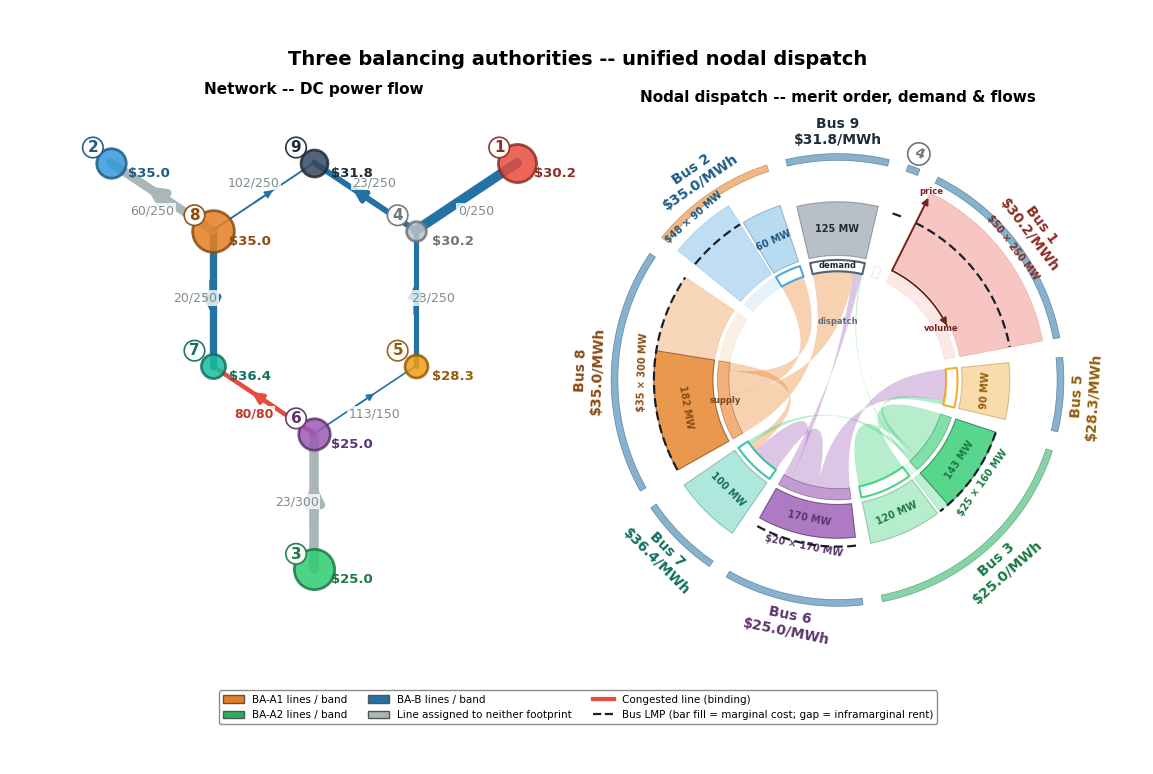

In [3]:
# -- EDIT -- the three-BA fleet/loads and the BA partition -------------------
# Nodes 2 and 3 each carry gen + load (self-sufficient); the cheap units sit at
# nodes 6 and 8. BA-A1 and BA-A2 are single-node BAs; BA-B is the rest.
GEN_FLEET = dict(wm.FLEET_3BA)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.LOADS_3BA)   # {bus: MW}
BA_DEFS = {
    'BA-A1': ['2'],                                  # single-node BA at node 2 (pricier)
    'BA-A2': ['3'],                                  # single-node BA at node 3 (cheaper, surplus)
    'BA-B':  ['1', '4', '5', '6', '7', '8', '9'],    # the rest of the network
}
BA_COLORS  = {'BA-A1': '#E67E22', 'BA-A2': '#27AE60', 'BA-B': '#2471A3'}
BA_MANAGES = {'BA-B': ['line_0', 'line_1', 'line_2', 'line_4', 'line_5', 'line_7', 'line_8']}
LINE_RATINGS = {'line_4': 80.0}      # a congested internal BA-B line (base flow ~93 MW)
# ---------------------------------------------------------------------------
net = wm.build_network(LINE_RATINGS); pt = compute_ptdf(net, slack_bus='1')
fp  = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_MANAGES)
unified = wm.make_engine('UNIFIED', buses=pt.buses, gen_fleet=GEN_FLEET, loads=LOADS)
res = solve_engine_dispatch(pt, unified, shed_price=150.0)

# Bus colours follow the three-BA fleet so the newly-active nodes 6/8 get colours.
_sup = {}
for _g, _s in GEN_FLEET.items():
    _sup.setdefault(_s['bus'], []).append(_s)
BUS_COLORS_3BA = assign_bus_colors(pt.buses, _sup, LOADS)

print('three BAs:', {k: v for k, v in BA_DEFS.items()})
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items() if v > 0.1})
print('LMPs ($/MWh):', {b: round(res.lmp[b], 1) for b in pt.buses})
figs.footprint_figure(net, pt, fp, unified, res, bus_colors=BUS_COLORS_3BA,
                      suptitle='Three balancing authorities -- unified nodal dispatch')
plt.show()

## 2. Per-BA settlement, and the congestion rent

The settlement extends to three areas exactly as it did to two: each BA's
generators are paid \(\lambda_n g_n\) and its load pays \(\lambda_n d_n\) at the nodal
LMPs. The **congestion rent** \(R\) — what load pays minus what generation is paid —
is money the system holds; it lands in the TOTAL column. Each BA collects the part
its own prices create (load payment − generator revenue). **Allocating that pooled
rent between the BAs is a policy choice**, not a fact of the dispatch.

In [4]:
s = ra.ba_settlement(fp, res, LOADS)
tbl = pd.DataFrame({a: {
    'Load payment  (lmp x d)':                          s[a]['load_pay'],
    'Generator revenue  (lmp x g)':                     s[a]['gen_rev'],
    'Congestion rent collected  (load pay - gen rev)':  s[a]['net_into_pool'],
} for a in fp.areas})
tbl['TOTAL'] = tbl.sum(axis=1)
R = tbl.loc['Congestion rent collected  (load pay - gen rev)', 'TOTAL']
print(f'congestion rent  R = ${R:,.1f}/h  -- held by the system (the TOTAL column); '
      f'allocating it between the BAs is a policy choice.')
display(tbl.round(1))

congestion rent  R = $1,072.1/h  -- held by the system (the TOTAL column); allocating it between the BAs is a policy choice.

,BA-A1,BA-A2,BA-B,TOTAL
Load payment (lmp x d),2100.0,3000.0,10171.8,15271.8
Generator revenue (lmp x g),0.0,3563.4,10636.2,14199.6
Congestion rent collected (load pay - gen rev),2100.0,-563.4,-464.4,1072.1


## 3. Do all three BAs gain vs going it alone? (autarky Pareto test)

Each BA could instead serve its own load on its own resources — **autarky**. A
single-node BA just balances locally at its own marginal cost (node 2 at \$48, node 3
at \$25). Is every BA at least as well off under the unified clearing? The check needs
the pooled rent rebated *somehow*; we use the simplest neutral default — **rebate to
load pro-rata by load share** (one general uplift methodology; allocation rules are
the subject of the congestion-revenue-allocation track).

In [5]:
_, indep = ra.independent_clear(fp, LINE_RATINGS, gen_fleet=GEN_FLEET,
                                 loads=LOADS, shed_price=150.0)
_R = sum(ra.ba_settlement(fp, res, LOADS)[a]['net_into_pool'] for a in fp.names)
_load = {a: sum(LOADS.get(b, 0.0) for b in fp.defs[a]) for a in fp.names}
prorata = pd.DataFrame({'method1': {a: _R * _load[a] / sum(_load.values()) for a in fp.names}})
print('autarky energy prices:',
      {a: (f'${indep[a].energy_price:.0f}' if indep[a] else 'INFEASIBLE') for a in fp.names})
print('congestion rent rebated pro-rata by load share:',
      {a: round(prorata.loc[a, 'method1'], 1) for a in fp.names})
display(ra.autarky_vs_unified(fp, 1, prorata, indep, res, LOADS, ra.cost_by_bus(GEN_FLEET)))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


autarky energy prices:

{'BA-A1': '$48', 'BA-A2': '$25', 'BA-B': '$35'}

congestion rent rebated pro-rata by load share:

{'BA-A1': np.float64(130.0), 'BA-A2': np.float64(259.9), 'BA-B': np.float64(682.3)}

BA-A1              BA-A2               BA-B          
                                   Consumer Generator Consumer Generator Consumer Generator
Autarky: payment / revenue          -2880.0    2880.0  -3000.0    3000.0 -11025.0   11025.0
Autarky: production cost                      -2880.0            -3000.0            -8475.0
Autarky: own congestion rent (CRR)      0.0                0.0                0.0          
Autarky: position                   -2880.0       0.0  -3000.0       0.0 -11025.0    2550.0
Unified: payment / revenue          -2100.0       0.0  -3000.0    3563.4 -10171.8   10636.2
Unified: production cost                         -0.0            -3563.4            -9786.2
Congestion rent (CRR)                 130.0              259.9              682.3          
Final position                      -1970.0       0.0  -2740.1       0.0  -9489.5     850.0
Delta vs autarky                      910.0       0.0    259.9       0.0   1535.5   -1700.0
Pareto (Delta >= 0)                     yes       yes      yes       yes      yes        no

## 4. Where this goes next

Three balancing authorities, one shared grid, one nodal clearing. The next notebook
in this track groups **BA-A1 and BA-A2 into one market** that are *not electrically
connected* and coordinate only through a **transfer**, and lets **BA-B** wheel that
transfer across its network — the Markets+/EDAM seam, and how the transaction
settles in each market.